In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("event-logs.csv")

---
# Quick look at the shape of the data

-50,240 rows  
-3% of the data in the 'Entity Details' column is null (i.e. missing)  
-All column data types are string objects (text)  

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50240 entries, 0 to 50239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Timestamp       50240 non-null  str  
 1   User            50240 non-null  str  
 2   Event Type      50240 non-null  str  
 3   Entity Type     50240 non-null  str  
 4   Entity Details  48759 non-null  str  
 5   Event Id        50240 non-null  str  
dtypes: str(6)
memory usage: 2.3 MB


In [4]:
df.head(2)

,Timestamp,User,Event Type,Entity Type,Entity Details,Event Id
0,2026-04-25T03:35:06.211Z,Investigations,read,stream,Interaction: View Live Stream\nCamera Name: C#...,e6f0f896-7937-505c-bd1a-99cdec24f680
1,2026-04-25T03:35:05.934Z,Investigations,read,stream,Interaction: View Live Stream\nCamera Name: C#...,26661c87-f7c8-540b-8774-7bad7909bf19


In [5]:
# Fill in a bunch of empty data in the 'Entity Details' column
df = df.fillna("", inplace = True)

---
# Check 'Entity Details' column

This column contains descriptive details about the entity (seems to be mostly the cameras) that receives the event/action

In [6]:
df['Entity Details'].value_counts().to_frame('count').reset_index().head(20).iloc[6]['Entity Details']

'Interaction: View Live Stream\nCamera Name: C#004 Planet Fitness\n'

#### Let's see how many cameras are connected to the system...

In [7]:
# Extract the name of the unique cameras from the column
uniquecameras = []

for i in range(len(df)):

    # some values are floats, ignore these
    if type(df['Entity Details'][i]) != float:

        # split the list object on new line
        x = df['Entity Details'][i].split("\n")
        
        for j in x:
            
            # search the string for the substring 'Camera Name' and add to list 
            # if it's not there to get the unique camera names
            if 'Camera Name' in j and j not in uniquecameras:
                uniquecameras.append(j)

            else:
                pass

#### The city of Coon Rapids has an MOU with Anoka County for [12 Flock ALPRs](https://public.destinyhosted.com/agenda_publish.cfm?dsp=agm&seq=10032&rev=0&id=26667&form_type=AG_MEMO&beg_meetmth=1&beg_meetyr=2015&end_meetmth=7&end_meetyr=2026&mt=ALL&sstr=Flock&dept=ALL&hartkeywords=&sortby=f.form_num,%20f.rev_num&fp=ADVSRCH&StartRow=1)
##### This is in addition to the [6 Flock ALPRs in Riverdale](https://public.destinyhosted.com/agenda_publish.cfm?dsp=agm&seq=9617&rev=0&id=26667&form_type=AG_MEMO&beg_meetmth=1&beg_meetyr=2015&end_meetmth=7&end_meetyr=2026&mt=ALL&sstr=Flock&dept=ALL&hartkeywords=&sortby=f.form_num,%20f.rev_num&fp=ADVSRCH&StartRow=1)
##### However, it is clear in the data below that the city has connected many of their already-owned cameras into the Flock system.

In [8]:
len(uniquecameras)

99

In [9]:
uniquecameras

['Camera Name: C#015 Lions Park Restrooms',
 'Camera Name: C#013 Lions Park Basketball',
 'Camera Name: C#004 Planet Fitness',
 'Camera Name: C#006 Ulta Beauty @ River Rapids Dr - PTZ',
 "Camera Name: C#008 Dick's Sporting Goods",
 'Camera Name: C#001 Round Lake/Riverdale Blvd',
 'Camera Name: C#002 Riverdale Blvd @ Main St - PTZ',
 'Camera Name: C#007 Famous Footwear',
 'Camera Name: C#009 Buffalo Wild Wings @ River Rapids Dr - PTZ',
 'Camera Name: C#04 Crooked Lake Shelter 2',
 'Camera Name: C#03 Crooked Lake Restrooms',
 'Camera Name: C#05 Crooked Lake Parking lot',
 'Camera Name: C#01 Crooked Lake Beach',
 'Camera Name: C#02 Crooked Lake Fishing Piers',
 'Camera Name: C#014 Lions Park Shelter 2',
 'Camera Name: C#016 Lions Park Playground',
 'Camera Name: C#006 Lions Park South Lot',
 'Camera Name: C#012 Schneiderman’s Side Lot',
 'Camera Name: C#003 Riverdale Village Playground @ River Rapids Dr - PTZ',
 'Camera Name: C#010 Noodles & Company',
 'Camera Name: C#011 Schneiderman’s',

---
# A little data prep...

In [10]:
# Create 'Event Action' column, which contains the first string element
# from the string (split on new line) in the 'Entity Details' column.
# This is the 'interaction' type
df['Event Action'] = [x.split("\n")[0] for x in df['Entity Details']]

In [11]:
# Examine the event types (the kinds of actions taken in the system)
df['Event Type'].value_counts()

Event Type
update    35077
read      14860
create      253
delete       50
Name: count, dtype: int64

In [12]:
# Create DataFrames for each Event Type
dfcreate = df[df['Event Type'] == 'create'].reset_index(drop = True)
dfdelete = df[df['Event Type'] == 'delete'].reset_index(drop = True)
dfread = df[df['Event Type'] == 'read'].reset_index(drop = True)
dfupdate = df[df['Event Type'] == 'update'].reset_index(drop = True)

In [13]:
# All Entity Types
df['Entity Type'].value_counts()

Entity Type
stream                     47822
search                      1478
role                         370
user                         334
Custom Hotlist Entry         109
networkShare                  36
customHotlist                 30
location                      14
organization                  13
networkShareSettings           9
vehicleDescriptionAlert        8
shareRequest                   7
accountContact                 7
integration                    3
Name: count, dtype: int64

---
# Exploratory Data Analaysis (EDA)
#### Let's dig in
---

Quick look at integrations. What's being integrated into the system?

In [14]:
df[df['Entity Type'] == 'integration']

,Timestamp,User,Event Type,Entity Type,Entity Details,Event Id,Event Action
11214,2026-03-12T16:10:40.002Z,Cindy Hintze,create,integration,Message: Creating an Integration\nIntegration ...,fbd125bc-a6a1-5893-9f04-82ba371df272,Message: Creating an Integration
44913,2025-07-15T14:32:00.974Z,Adam Knauer,create,integration,Message: Creating an Integration\nIntegration ...,23490bc5-cfd6-5bb7-9466-e884c6a8a024,Message: Creating an Integration
44955,2025-07-15T12:20:50.155Z,Adam Knauer,create,integration,Message: Creating an Integration\nIntegration ...,84dc4e97-95b7-59bf-a78b-00bcf06ae238,Message: Creating an Integration


In [15]:
# Axon evidence system??
df[df['Entity Type'] == 'integration']['Entity Details'][44913].split("\n")

['Message: Creating an Integration',
 'Integration Name: Axon Evidence',
 'Catalog Entry ID: b5bc1746-cb0e-4b73-a5c3-afc8345f4de2',
 '']

In [16]:
# This is likely Microsoft SSO for users to sign into the system using their ciy Microsoft acount
df[df['Entity Type'] == 'integration']['Entity Details'][44955].split("\n")

['Message: Creating an Integration',
 'Integration Name: Microsoft Entra ID',
 'Catalog Entry ID: MicrosoftEntraID',
 '']

In [17]:
# An API integration with a big technology company. 
# That's...concerning.
df[df['Entity Type'] == 'integration']['Entity Details'][11214].split("\n")

['Message: Creating an Integration',
 'Integration Name: V3 API (Tyler Technologies)',
 'Catalog Entry ID: f8c8d615-959d-4906-9eec-b4e6f6deb508',
 '']

---
# Ok. Let's start small: What kinds of things are 'created'?

Seems to be mainly the creation of users, but also hotlist entries

In [18]:
dfcreate['Entity Type'].value_counts()

Entity Type
user                       101
Custom Hotlist Entry        78
networkShare                34
customHotlist               13
role                         9
shareRequest                 7
accountContact               4
integration                  3
vehicleDescriptionAlert      3
organization                 1
Name: count, dtype: int64

In [19]:
# Make a networkShare DataFrame to see who has been given access to the Coon Rapids database
dfns = dfcreate[dfcreate['Entity Type'] == 'networkShare'].reset_index(drop = True)

In [20]:
# See what the data looks like...
dfns['Entity Details'][4].split("\n")

['Network Name: Coon Rapids MN PD Pole Cameras',
 'Permissions: feedView, hotlistToolAccess, canViewLiveStream, canViewRecordedStream, canDownloadRecordedStream, canModifyImagingSettings, canUsePtz, canModifyPtzSettings',
 'Receiving Organization: Blaine MN PD',
 '']

In [21]:
# Network shares show the organizations with whom Coon Rapids is sharing access.
# Make a list of all orgs who have access to CR cameras.
orgs = []

for i in range(len(dfns)):

    # grab the third item in the split list, remove text so as to keep the org name only
    o = dfns['Entity Details'][i].split("\n")[2].replace("Receiving Organization: ", "")

    if o not in orgs:
        orgs.append(o)


#### The entities that have varying levels of access to the Coon Rapids Flock system

In [22]:
orgs

['Spring Lake Park MN PD',
 'Blaine MN PD',
 'Hopkins MN PD',
 'Grand Rapids MN PD',
 'Anoka County MN SO',
 'Hennepin County MN SO',
 'Minnetonka MN PD',
 'Cottage Grove Public Safety Dept (MN)',
 'Maplewood MN PD',
 'Ramsey MN PD',
 'St. Louis Park MN PD',
 'Fridley MN PD',
 'Elk River MN PD',
 'None',
 'Osceola WI PD']

---
# Read

In [23]:
dfread['Event Action'].value_counts()

Event Action
Interaction: View Live Stream        13248
                                      1478
Interaction: View Recorded Stream      133
Interaction: Download Stream             1
Name: count, dtype: int64

#### 'Read' events are of two types: watching a camera's stream, and searching for something

In [24]:
dfread['Entity Type'].value_counts()

Entity Type
stream    13382
search     1478
Name: count, dtype: int64

#### Let's make a searches DataFrame and see who is searching for what

In [25]:
dfsearches = dfread[dfread['Entity Type'] == 'search'].reset_index(drop = True)

#### No search data is preserved in the log, so we don't know what they're typing when they search

In [26]:
dfsearches['Entity Details'].value_counts()

Entity Details
    1478
Name: count, dtype: int64

#### But who has done the searching?

In [27]:
dfsearches['User'].value_counts()

User
John Ormston                          351
Cory Lindsholm                        248
Georgia Carlson                       174
Steven Minion                         144
Adam Jacobson                          94
Doug Barron                            88
Stephanie Ring                         68
Geoff Neumann                          48
Autumn Nelson                          48
David Genovese                         37
Adam Backman                           37
Danielle Forsman                       31
Investigations                         26
Dzevad Mahmutovic                      19
Tyler Soine                            18
Cindy Hintze                           15
Daniel Ehnstrom                        14
Josh Pirkola                            8
Lindsey Wiczek                          4
Anthony Guzdkiewicz                     2
Redacted per MSS 13.82 subd. 17(a)      2
Ryan Gunderson                          2
Name: count, dtype: int64

#### Let's make a visualization of the number of searches over time

In [28]:
# Convert timestamp string column
dfsearches['Timestamp'] = pd.to_datetime(dfsearches['Timestamp'])

# Add DateString column and month and year columns for groupby counting
dfsearches['DateString'] = [x.strftime("%m/%d/%Y") for x in dfsearches['Timestamp']]
dfsearches['Year'] = [x.year for x in dfsearches['Timestamp']]
dfsearches['Month'] = [x.month for x in dfsearches['Timestamp']]
dfsearches['Day'] = [x.day for x in dfsearches['Timestamp']]

In [29]:
# Groupby
dfSearch2 = dfsearches.groupby(['DateString'])['Event Action'].count().to_frame('Search Count').reset_index()

# Create a date column for sorting only
dfSearch2['SortDate'] = pd.to_datetime(dfSearch2['DateString'])

# Sort
dfSearch2Sort = dfSearch2.sort_values(['SortDate']).reset_index(drop = True)

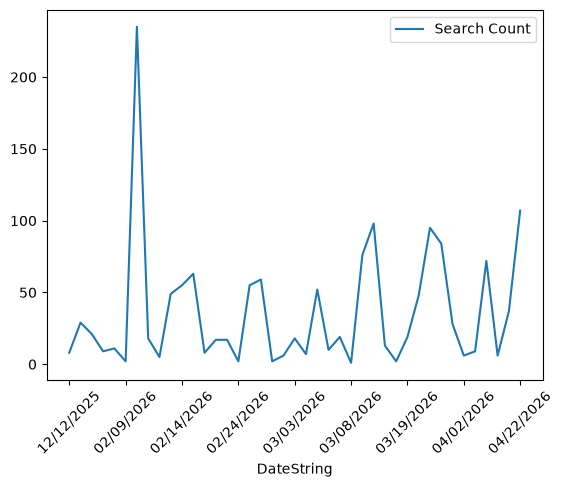

In [30]:
dfSearch2Sort.plot(kind = 'line', x = 'DateString', y = 'Search Count', rot = 45);

#### The search spike in early February correlates with heightened Metro Surge activity in MN.
#### Let's check out who searched.

In [31]:
dfsearchFeb = dfsearches[(dfsearches['Month'] == 2) & (dfsearches['Day'] == 10)].reset_index(drop = True)

In [32]:
dfsearchFeb['User'].value_counts()

User
John Ormston     221
Steven Minion     14
Name: count, dtype: int64

---
# What live streams are viewed the most?

In [33]:
dflive = df[df['Event Action'] == 'Interaction: View Live Stream'].reset_index(drop = True)

In [34]:
dflive.head(2)

,Timestamp,User,Event Type,Entity Type,Entity Details,Event Id,Event Action
0,2026-04-25T03:35:06.211Z,Investigations,read,stream,Interaction: View Live Stream\nCamera Name: C#...,e6f0f896-7937-505c-bd1a-99cdec24f680,Interaction: View Live Stream
1,2026-04-25T03:35:05.934Z,Investigations,read,stream,Interaction: View Live Stream\nCamera Name: C#...,26661c87-f7c8-540b-8774-7bad7909bf19,Interaction: View Live Stream


#### Get the second line of text from the 'Entity Details' column to get the camera name

In [35]:
dflive['Camera'] = [x.split("\n")[1] for x in dflive['Entity Details']]

#### They sure keep an eye on Lions park my goodness.

%30 of all data in this event log is live stream views of 4 cameras at Lions Park

In [36]:
dflive.Camera.value_counts()

Camera
Camera Name: C#013 Lions Park Basketball                                  6409
Camera Name: C#014 Lions Park Shelter 2                                   4866
Camera Name: C#015 Lions Park Restrooms                                   2290
Camera Name: C#006 Lions Park South Lot                                   2068
Camera Name: Trailer A PTZ camera (Axis)                                  1939
                                                                          ... 
Camera Name: Trailer Axis Quad All four                                      2
Camera Name: C#001 Blakeslee Blvd Dr (PA-443) @ S 9th St (PA-902) - SW       1
Camera Name: C#001 75 NB Onramp @ Golden Gate Pkwy                           1
Camera Name: C#001 Freemont Park                                             1
Camera Name: #14 Two Notch Rd @ Oakcrest Dr (aims outbound)                  1
Name: count, Length: 96, dtype: int64

---
# 'Update' event types
#### This is the most prominent kind of action in the system. 70% of all activity is 'update'

In [37]:
# Quick look
dfupdate.head(2)

,Timestamp,User,Event Type,Entity Type,Entity Details,Event Id,Event Action
0,2026-04-24T15:59:35.586Z,Trish Heitman,update,location,Name: C#021 Lions Coon Creek Park -> P#021 Lio...,c802b472-0d8a-5898-8bb7-5dc74d6e8b9f,Name: C#021 Lions Coon Creek Park -> P#021 Lio...
1,2026-03-25T14:03:09.947Z,Trish Heitman,update,user,Name: Tyler Soine\nRoleName: Patrol -> Patrol ...,a30dfcd3-f1b4-5d0f-b93f-bf0addf4b0ee,Name: Tyler Soine


#### Count of entity types in the 'update' DataFrame
Primarily viewing livestreams

In [38]:
dfupdate['Entity Type'].value_counts()

Entity Type
stream                     34440
role                         358
user                         225
location                      14
organization                  12
networkShareSettings           9
Custom Hotlist Entry           8
customHotlist                  6
accountContact                 2
vehicleDescriptionAlert        2
networkShare                   1
Name: count, dtype: int64

#### Make DataFrames of all the other 'Entity Types' that are updated

In [39]:
dfUpdNS = dfupdate[dfupdate['Entity Type'] == 'networkShare'].reset_index(drop = True)
dfUpdVDA = dfupdate[dfupdate['Entity Type'] == 'vehicleDescriptionAlert'].reset_index(drop = True)
dfUpdAC = dfupdate[dfupdate['Entity Type'] == 'accountContact'].reset_index(drop = True)
dfUpdCH = dfupdate[dfupdate['Entity Type'] == 'customHotlist'].reset_index(drop = True)
dfUpdCHE = dfupdate[dfupdate['Entity Type'] == 'Custom Hotlist Entry'].reset_index(drop = True)
dfUpdNet = dfupdate[dfupdate['Entity Type'] == 'networkShareSettings'].reset_index(drop = True)
dfUpdOrg = dfupdate[dfupdate['Entity Type'] == 'organization'].reset_index(drop = True)
dfUpdLoc = dfupdate[dfupdate['Entity Type'] == 'location'].reset_index(drop = True)
dfUpdUser = dfupdate[dfupdate['Entity Type'] == 'user'].reset_index(drop = True)
dfUpdRole = dfupdate[dfupdate['Entity Type'] == 'role'].reset_index(drop = True)

In [40]:
dfUpdOrg.head(5)

,Timestamp,User,Event Type,Entity Type,Entity Details,Event Id,Event Action
0,2026-02-11T13:19:52.429Z,Emmie Smith,update,organization,Immigration Enforcement: Enabled search policy...,a0d50287-ebdd-5c7f-b4a9-e2e0c114bd42,Immigration Enforcement: Enabled search policy...
1,2025-12-11T14:59:58.521Z,Trish Heitman,update,organization,Search Reason Formatting: Free Text -> Custom ...,a044ac6d-d9af-5966-a68f-a9199361e6e1,Search Reason Formatting: Free Text -> Custom ...
2,2025-12-11T14:46:11.506Z,Trish Heitman,update,organization,Immigration Enforcement: Enabled search policy...,ac5e23cf-c255-53d9-9a13-19fed7b414a0,Immigration Enforcement: Enabled search policy...
3,2025-11-14T18:04:44.231Z,Mike Solomon,update,organization,Can View Traffic Analytics: Disabled -> Enabled\n,a9ab7d14-a30d-5f51-a1a0-92595588a12b,Can View Traffic Analytics: Disabled -> Enabled
4,2025-09-24T20:16:28.598Z,Trish Heitman,update,organization,Statewide Lookup: Enabled -> Disabled\n,774b4192-c6a7-5a1f-803f-9c4f51fa4914,Statewide Lookup: Enabled -> Disabled


# WOAH Immigration Enforcement? Isn't that supposed to be a Fed only activity?

In [41]:
dfUpdOrg.iloc[2]['Entity Details'].split("\n")

['Immigration Enforcement: Enabled search policy for 6 networks',
 'Reproductive Health: Enabled search policy for 6 networks',
 '']

## Ok, what on earth is this? It appears multiple 'networks' (whatever those are) can search in Coon Rapids Flock system for immigration enforcement and reproductive health???? What?


---

# Overall live stream views over time

In [42]:
dflivestream = df[df['Event Action'] == 'Interaction: View Live Stream'].reset_index(drop = True)

In [43]:
dflivestream['Timestamp'] = pd.to_datetime(dflivestream['Timestamp'])

In [44]:
# Add DateString column and month and year columns for groupby counting
dflivestream['DateString'] = [x.strftime("%m/%d/%Y") for x in dflivestream['Timestamp']]
dflivestream['DateStringAMPM'] = [x.strftime("%m/%d/%Y %I:%M %p") for x in dflivestream['Timestamp']]
dflivestream['Year'] = [x.year for x in dflivestream['Timestamp']]
dflivestream['Month'] = [x.month for x in dflivestream['Timestamp']]
dflivestream['Day'] = [x.day for x in dflivestream['Timestamp']]

In [45]:
dfLS2 = dflivestream.groupby(['Year', 'Month', 'Day'])['Event Action'].count().to_frame('Livestream Views').reset_index()

In [46]:
dfLS3 = dflivestream.groupby(['DateString'])['Event Action'].count().to_frame('Livestream Views').reset_index()

In [47]:
dfLS3['SortDate'] = pd.to_datetime(dfLS3['DateString'])

In [48]:
dfLS3sort = dfLS3.sort_values(['SortDate']).reset_index(drop = True)

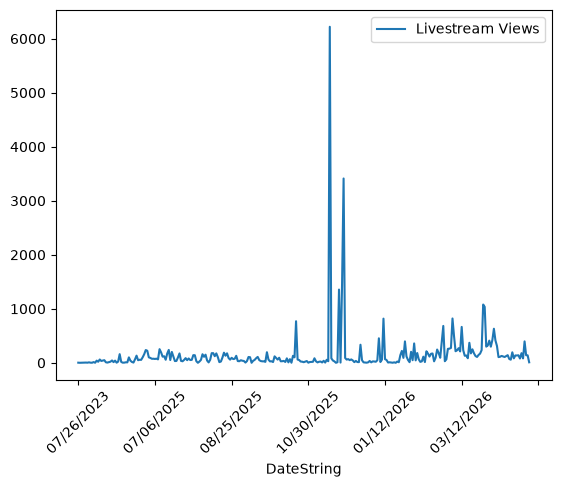

In [49]:
dfLS3sort.plot(kind = 'line', x = 'DateString', y = 'Livestream Views', rot = 45);